# PWS Sample Data - Quick Read and Visualize
## Weather Underground Personal Weather Stations (Jan 15-30, 2024)

This notebook demonstrates how to read and visualize the PWS sample dataset in OpenSense-1.0 format.

In [43]:
import netCDF4 as nc
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np


def plot_pws_data(pws_data, start_date, end_date, station_list=None, variable='rainfall_amount'):
    """
    Plot PWS data for selected stations and date range.

    Parameters:
    -----------
    pws_data : dict
        Dictionary of xarray fetch_data (one per station)
    start_date : str
        Start date in 'YYYY-MM-DD' format
    end_date : str
        End date in 'YYYY-MM-DD' format
    station_list : list or None
        List of station names to plot. If None, plots all stations.
    variable : str
        Variable to plot (default: 'rainfall_amount')
    """

    # If no station list provided, use all stations
    if station_list is None:
        station_list = list(pws_data.keys())

    # Filter to only stations that exist in the data
    available_stations = [s for s in station_list if s in pws_data]

    if len(available_stations) == 0:
        print("⚠ No valid stations found!")
        return

    print(f"Plotting {len(available_stations)} stations from {start_date} to {end_date}")
    print(f"Variable: {variable}")
    print("="*70)

    # Create subplots
    n_stations = len(available_stations)
    n_cols = 2
    n_rows = (n_stations + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
    if n_stations == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for idx, station_name in enumerate(available_stations):
        ax = axes[idx]
        station_ds = pws_data[station_name]

        try:
            # Select date range
            station_subset = station_ds.sel(time=slice(start_date, end_date))

            if len(station_subset['time']) == 0:
                ax.text(0.5, 0.5, f'No data in date range',
                       ha='center', va='center', transform=ax.transAxes)
                ax.set_title(station_name, fontsize=10, fontweight='bold')
                continue

            # Plot the variable
            if variable in station_subset.data_vars:
                if variable == 'rainfall_amount':
                    # Plot cumulative for rainfall amount
                    cumsum = station_subset[variable].cumsum(dim='time')
                    cumsum.plot(ax=ax, linewidth=2, color='navy')
                    total = float(station_subset[variable].sum().values)
                    ax.set_ylabel('Accumulated Rainfall (mm)', fontsize=10)
                    ax.set_title(f'{station_name}\nTotal: {total:.1f} mm',
                                fontsize=10, fontweight='bold')
                else:
                    # Plot regular time series for other variables
                    station_subset[variable].plot(ax=ax, linewidth=1.5, color='steelblue')
                    ax.set_ylabel(f"{variable.replace('_', ' ').title()}", fontsize=10)
                    ax.set_title(station_name, fontsize=10, fontweight='bold')

                ax.set_xlabel('Time', fontsize=10)
                ax.grid(True, alpha=0.3)
            else:
                ax.text(0.5, 0.5, f'Variable {variable} not found',
                       ha='center', va='center', transform=ax.transAxes)
                ax.set_title(station_name, fontsize=10, fontweight='bold')

        except Exception as e:
            ax.text(0.5, 0.5, f'Error: {str(e)}',
                   ha='center', va='center', transform=ax.transAxes, fontsize=8)
            ax.set_title(station_name, fontsize=10, fontweight='bold')

    # Hide unused subplots
    for idx in range(n_stations, len(axes)):
        axes[idx].axis('off')

    fig.suptitle(f'PWS {variable.replace("_", " ").title()} ({start_date} to {end_date})',
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

    print(f"\n✓ Plotted {len(available_stations)} stations")


def read_netcdf_groups_to_xarray_dict(ds):
    """
    Convert open netCDF4 groups to dict of xarray Datasets.
    """
    print(f"\n{'=' * 70}")
    print("CONVERTING NETCDF GROUPS TO XARRAY DICT")
    print(f"{'=' * 70}\n")

    stations = {}

    for station_id in ds.groups.keys():
        try:
            station_ds = xr.open_dataset(ds.filepath(), group=station_id, engine='netcdf4')
            stations[station_id] = station_ds
            print(f"  ✓ {station_id}: {len(station_ds.time)} records")
        except Exception as e:
            print(f"  ❌ {station_id}: {e}")

    print(f"\n✓ Converted {len(stations)} stations")
    print(f"{'=' * 70}\n")

    return stations


def plot_pws_accumulated_rainfall(pws_data, start_date, end_date, station_list=None):
    """
    Plot accumulated rainfall for selected stations and date range.

    Parameters:
    -----------
    pws_data : dict
        Dictionary of xarray fetch_data (one per station)
    start_date : str
        Start date in 'YYYY-MM-DD' format
    end_date : str
        End date in 'YYYY-MM-DD' format
    station_list : list or None
        List of station names to plot. If None, plots all stations.
    """

    # If no station list provided, use all stations
    if station_list is None:
        station_list = list(pws_data.keys())

    # Filter to only stations that exist in the data
    available_stations = [s for s in station_list if s in pws_data]

    if len(available_stations) == 0:
        print("⚠ No valid stations found!")
        return

    print(f"Plotting accumulated rainfall for {len(available_stations)} stations")
    print(f"Period: {start_date} to {end_date}")
    print("="*70)

    # Create subplots
    n_stations = len(available_stations)
    n_cols = 2
    n_rows = (n_stations + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
    if n_stations == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for idx, station_name in enumerate(available_stations):
        ax = axes[idx]
        station_ds = pws_data[station_name]

        try:
            # Select date range
            station_subset = station_ds.sel(time=slice(start_date, end_date))

            if len(station_subset['time']) == 0:
                ax.text(0.5, 0.5, f'No data in date range',
                       ha='center', va='center', transform=ax.transAxes)
                ax.set_title(station_name, fontsize=10, fontweight='bold')
                continue

            # Calculate cumulative rainfall
            if 'rainfall_amount' in station_subset.data_vars:
                cumulative = station_subset['rainfall_amount'].cumsum(dim='time')
                total = float(station_subset['rainfall_amount'].sum().values)

                # Plot
                cumulative.plot(ax=ax, linewidth=2, color='navy')
                ax.set_ylabel('Accumulated Rainfall (mm)', fontsize=10)
                ax.set_xlabel('Time', fontsize=10)
                ax.set_title(f'{station_name}\nTotal: {total:.1f} mm',
                            fontsize=10, fontweight='bold')
                ax.grid(True, alpha=0.3)
            else:
                ax.text(0.5, 0.5, f'No rainfall_amount data',
                       ha='center', va='center', transform=ax.transAxes)
                ax.set_title(station_name, fontsize=10, fontweight='bold')

        except Exception as e:
            ax.text(0.5, 0.5, f'Error: {str(e)}',
                   ha='center', va='center', transform=ax.transAxes, fontsize=8)
            ax.set_title(station_name, fontsize=10, fontweight='bold')

    # Hide unused subplots
    for idx in range(n_stations, len(axes)):
        axes[idx].axis('off')

    fig.suptitle(f'Accumulated Rainfall ({start_date} to {end_date})',
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

    print(f"\n✓ Plotted accumulated rainfall for {len(available_stations)} stations")


def plot_pws_ensemble_rainfall(pws_data, start_date, end_date, station_list=None,
                                resample_interval='15min', show_individual=True,
                                filter_top_n=0, filter_bottom_n=0):
    """
    Plot all stations on a single plot with spatial aggregation statistics.
    
    Individual stations are shown with low alpha, plus aggregated statistics
    (max, min, mean, median) computed across all stations at each time step.
    
    Parameters:
    -----------
    pws_data : dict
        Dictionary of xarray Datasets (one per station)
    start_date : str
        Start date in 'YYYY-MM-DD' format
    end_date : str
        End date in 'YYYY-MM-DD' format
    station_list : list or None
        List of station names to plot. If None, uses all stations.
    resample_interval : str
        Time interval for resampling before aggregation (default: '15min')
    show_individual : bool
        Whether to show individual station traces (default: True)
    filter_top_n : int
        Number of top (highest total) stations to exclude (default: 0)
    filter_bottom_n : int
        Number of bottom (lowest total) stations to exclude (default: 0)
        
    Notes:
    ------
    Aggregation is SPATIAL at each time step:
    - max: maximum accumulated rainfall across all stations at each time
    - min: minimum accumulated rainfall across all stations at each time
    - mean: average accumulated rainfall across all stations at each time
    - median: median accumulated rainfall across all stations at each time
    
    Use filter_top_n and filter_bottom_n to cut edge outliers.
    """
    import pandas as pd
    
    # Get station list
    if station_list is None:
        station_list = list(pws_data.keys())
    available_stations = [s for s in station_list if s in pws_data]
    
    if len(available_stations) == 0:
        print("⚠ No valid stations found!")
        return
    
    print(f"Plotting ensemble rainfall for {len(available_stations)} stations")
    print(f"Period: {start_date} to {end_date}")
    print(f"Resample interval: {resample_interval}")
    print("="*70)
    
    # Collect all station data, resampled to common time grid
    all_cumulative = []
    station_totals = {}
    
    for station_name in available_stations:
        try:
            station_ds = pws_data[station_name]
            station_subset = station_ds.sel(time=slice(start_date, end_date))
            
            if len(station_subset['time']) == 0 or 'rainfall_amount' not in station_subset.data_vars:
                continue
            
            # Convert to pandas Series and resample
            rainfall = station_subset['rainfall_amount'].to_series()
            
            # Handle MultiIndex by resetting and using only time
            if isinstance(rainfall.index, pd.MultiIndex):
                rainfall = rainfall.reset_index(level=[l for l in rainfall.index.names if l != 'time'], drop=True)
            
            # Ensure we have a DatetimeIndex
            if not isinstance(rainfall.index, pd.DatetimeIndex):
                rainfall.index = pd.to_datetime(rainfall.index)
            
            rainfall_resampled = rainfall.resample(resample_interval).sum()
            
            # Compute cumulative
            cumulative = rainfall_resampled.cumsum()
            cumulative.name = station_name
            all_cumulative.append(cumulative)
            station_totals[station_name] = float(cumulative.iloc[-1]) if len(cumulative) > 0 else 0
            
        except Exception as e:
            print(f"  ⚠ Skipping {station_name}: {e}")
            continue
    
    if len(all_cumulative) == 0:
        print("⚠ No valid data to plot!")
        return
    
    # Combine all stations into DataFrame (aligns on time index)
    df = pd.concat(all_cumulative, axis=1)
    df = df.ffill().fillna(0)  # Forward fill gaps, then fill remaining NaN with 0
    
    print(f"  ✓ Combined {len(df.columns)} stations, {len(df)} time steps")
    
    # Filter out extreme stations (cut edges)
    if filter_top_n > 0 or filter_bottom_n > 0:
        # Sort stations by total rainfall
        sorted_stations = sorted(station_totals.items(), key=lambda x: x[1])
        stations_to_keep = [s for s, _ in sorted_stations]
        
        # Remove bottom N (lowest totals)
        if filter_bottom_n > 0:
            removed_bottom = stations_to_keep[:filter_bottom_n]
            stations_to_keep = stations_to_keep[filter_bottom_n:]
            print(f"  ✓ Filtered out {filter_bottom_n} lowest stations: {removed_bottom}")
        
        # Remove top N (highest totals)
        if filter_top_n > 0:
            removed_top = stations_to_keep[-filter_top_n:]
            stations_to_keep = stations_to_keep[:-filter_top_n]
            print(f"  ✓ Filtered out {filter_top_n} highest stations: {removed_top}")
        
        # Keep only remaining stations
        df = df[[s for s in stations_to_keep if s in df.columns]]
        station_totals = {s: station_totals[s] for s in stations_to_keep if s in station_totals}
        print(f"  ✓ Remaining: {len(df.columns)} stations")
    
    # Compute spatial statistics at each time step
    stats = pd.DataFrame({
        'max': df.max(axis=1),
        'min': df.min(axis=1),
        'mean': df.mean(axis=1),
        'median': df.median(axis=1)
    })
    
    # Create figure
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Plot individual stations with low alpha
    if show_individual:
        for col in df.columns:
            ax.plot(df.index, df[col], alpha=0.15, linewidth=0.8, color='steelblue')
    
    # Plot aggregated statistics with distinct colors
    ax.plot(stats.index, stats['max'], linewidth=2.5, color='darkred', 
            label=f"Max (station: {max(station_totals, key=station_totals.get)})")
    ax.plot(stats.index, stats['min'], linewidth=2.5, color='darkgreen', 
            label=f"Min (station: {min(station_totals, key=station_totals.get)})")
    ax.plot(stats.index, stats['mean'], linewidth=2.5, color='navy', 
            label='Mean (spatial avg)')
    ax.plot(stats.index, stats['median'], linewidth=2.5, color='darkorange', 
            linestyle='--', label='Median')
    
    # Fill between min and max
    ax.fill_between(stats.index, stats['min'], stats['max'], 
                    alpha=0.1, color='gray', label='Min-Max range')
    
    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel('Accumulated Rainfall (mm)', fontsize=12)
    ax.set_title(f'PWS Ensemble Accumulated Rainfall\n{start_date} to {end_date} | {len(df.columns)} stations | {resample_interval} resolution',
                 fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\n{'='*70}")
    print("SUMMARY STATISTICS (Final accumulated values)")
    print(f"{'='*70}")
    print(f"  Max:    {stats['max'].iloc[-1]:.1f} mm")
    print(f"  Min:    {stats['min'].iloc[-1]:.1f} mm")
    print(f"  Mean:   {stats['mean'].iloc[-1]:.1f} mm")
    print(f"  Median: {stats['median'].iloc[-1]:.1f} mm")
    print(f"  Spread: {stats['max'].iloc[-1] - stats['min'].iloc[-1]:.1f} mm")
    print(f"\n✓ Plotted ensemble for {len(df.columns)} stations")



## Load PWS Data

In [44]:
# Choose which file to load
USE_SAMPLE = False  # Set to False for full dataset

# Available files
DATA_FILES = {
    'sample': 'pws_opensense_sample_jan.nc',  # Sample: Jan 15-30, 2024
    'full': 'pws_opensense_os.nc'              # Full dataset
}

import pandas as pd
data_file = DATA_FILES['sample'] if USE_SAMPLE else DATA_FILES['full']
ds_pws   = nc.Dataset(data_file, 'r')
pws_meta = pd.read_csv('../pws_metadata.csv')  # metadata is in parent folder

# Display global attributes
print(f"LOADED: {data_file}")
print("="*70)
print(f"Title: {ds_pws.title}")
print(f"Source: {ds_pws.source}")
if hasattr(ds_pws, 'sample_period'):
    print(f"Period: {ds_pws.sample_period}")
if hasattr(ds_pws, 'institution'):
    print(f"Institution: {ds_pws.institution}")
if hasattr(ds_pws, 'attribution'):
    print(f"Attribution: {ds_pws.attribution}")
if hasattr(ds_pws, 'license'):
    print(f"License: {ds_pws.license}")
elif hasattr(ds_pws, 'license_restrictions'):
    print(f"License: {ds_pws.license_restrictions}")
if hasattr(ds_pws, 'naming_convention'):
    print(f"Format: {ds_pws.naming_convention}")
if hasattr(ds_pws, 'sample_note'):
    print(f"\nNote: {ds_pws.sample_note}")
print("="*70)



LOADED: pws_opensense_os.nc
Title: Weather Underground PWS Data
Source: Weather Underground Personal Weather Station Network
Institution: Cellular Environmental Monitoring (CellEnMon) Lab, School of Electrical Engineering, Tel-Aviv University; Wireless and Mobile Networking (WiMNet) Lab, Department of Electrical Engineering, Columbia University
License: CC-BY-NC 4.0 – https://creativecommons.org/licenses/by-nc/4.0/
Format: OpenSense-PWS-1.0


In [45]:
# Convert to xarray dict
pws_data = read_netcdf_groups_to_xarray_dict(ds_pws)


CONVERTING NETCDF GROUPS TO XARRAY DICT

  ✓ KNYNEWYO1472: 60339 records
  ✓ KNYNEWYO1659: 69868 records
  ✓ KNYNEWYO1288: 67946 records
  ✓ KNYNEWYO1896: 68462 records
  ✓ KNYNEWYO1921: 52742 records
  ✓ KNYNEWYO1931: 48528 records
  ✓ KNYNEWYO1313: 70483 records
  ✓ KNYNEWYO1918: 53133 records
  ✓ KNYNEWYO1298: 69073 records
  ✓ KNYNEWYO1388: 71026 records
  ✓ KNYNEWYO1606: 61358 records
  ✓ KNYNEWYO1943: 43081 records
  ✓ KNYNEWYO1348: 70507 records
  ✓ KNYNEWYO1942: 43057 records
  ✓ KNYNEWYO1238: 67812 records
  ✓ KNYNEWYO1401: 69035 records
  ✓ KNYNEWYO1824: 70132 records
  ✓ KNYNEWYO343: 60083 records
  ✓ KNYNEWYO1626: 66276 records
  ✓ KNYNEWYO1747: 22389 records
  ✓ KNYNEWYO589: 70172 records
  ✓ KNYNEWYO1591: 56991 records
  ✓ KNYNEWYO638: 66471 records
  ✓ KNYNEWYO1796: 69497 records
  ✓ KNYNEWYO1805: 70530 records
  ✓ KNYNEWYO1622: 69973 records
  ✓ KNYNEWYO1024: 16098 records
  ✓ KNYNEWYO1533: 67813 records
  ✓ KNYNEWYO1651: 23516 records
  ✓ KNYNEWYO1120: 70760 records
 

## Inspect a Single Station

In [29]:
# Get first station as example
station_name = list(pws_data.keys())[0]
station = pws_data[station_name]

print(f"Station: {station_name}")

# Access latitude/longitude - they're scalar variables in PWS data
if 'latitude' in station.variables:
    lat = float(station['latitude'].values)
    lon = float(station['longitude'].values)
    print(f"Location: {lat:.4f}°N, {lon:.4f}°E")

    # Also check for altitude/elevation
    if 'altitude' in station.variables:
        alt = float(station['altitude'].values)
        print(f"Altitude: {alt:.1f} m")
else:
    print("Location: coordinates not found")

print(f"\nVariables:")
for var in station.data_vars:
    print(f"  - {var}")

print(f"\nCoordinates:")
for coord in station.coords:
    print(f"  - {coord}")

print(f"\nDataset structure:")
print(station)

Station: KNYNEWYO1472
Location: coordinates not found

Variables:
  - rainfall_rate
  - rainfall_amount
  - temperature
  - relative_humidity
  - wind_velocity
  - wind_direction
  - air_pressure

Coordinates:
  - time
  - id
  - lat
  - lon
  - elev

Dataset structure:
<xarray.Dataset> Size: 4MB
Dimensions:            (id: 1, time: 60339)
Coordinates:
  * time               (time) datetime64[ns] 483kB 2023-10-29T04:04:00 ... 20...
  * id                 (id) <U12 48B 'KNYNEWYO1472'
    lat                (id) float64 8B ...
    lon                (id) float64 8B ...
    elev               (id) float64 8B ...
Data variables:
    rainfall_rate      (id, time) float64 483kB ...
    rainfall_amount    (id, time) float64 483kB ...
    temperature        (id, time) float64 483kB ...
    relative_humidity  (id, time) float64 483kB ...
    wind_velocity      (id, time) float64 483kB ...
    wind_direction     (id, time) float64 483kB ...
    air_pressure       (id, time) float64 483kB ...


## Plot Accumulated and Rainfall for All Stations

Plotting 2 stations from 2024-01-20 to 2024-01-25
Variable: rainfall_amount


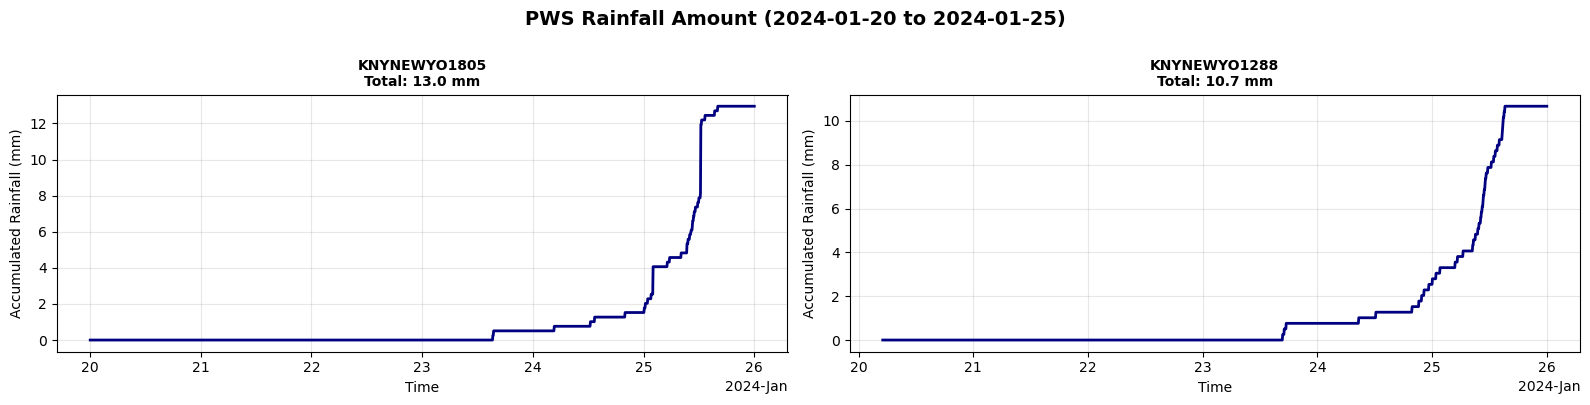


✓ Plotted 2 stations
Plotting 2 stations from 2024-01-15 to 2024-01-30
Variable: temperature


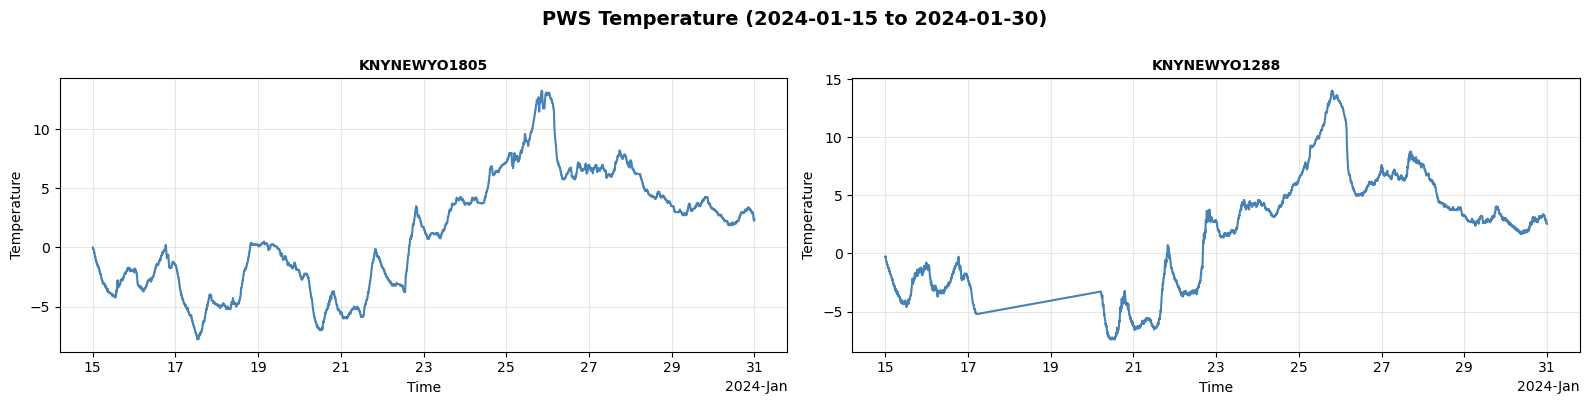


✓ Plotted 2 stations


In [30]:

# Example 2: Plot specific stations only
selected_stations = ['KNYNEWYO1805', 'KNYNEWYO1288']
plot_pws_data(pws_data,
              start_date='2024-01-20',
              end_date='2024-01-25',
              station_list=selected_stations,
              variable='rainfall_amount')

# Example 3: Plot temperature instead
plot_pws_data(pws_data,
              start_date='2024-01-15',
              end_date='2024-01-30',
              station_list=selected_stations,
              variable='temperature')



Plotting ensemble rainfall for 37 stations
Period: 2024-01-01 to 2024-01-30
Resample interval: 15min
  ✓ Combined 37 stations, 2880 time steps


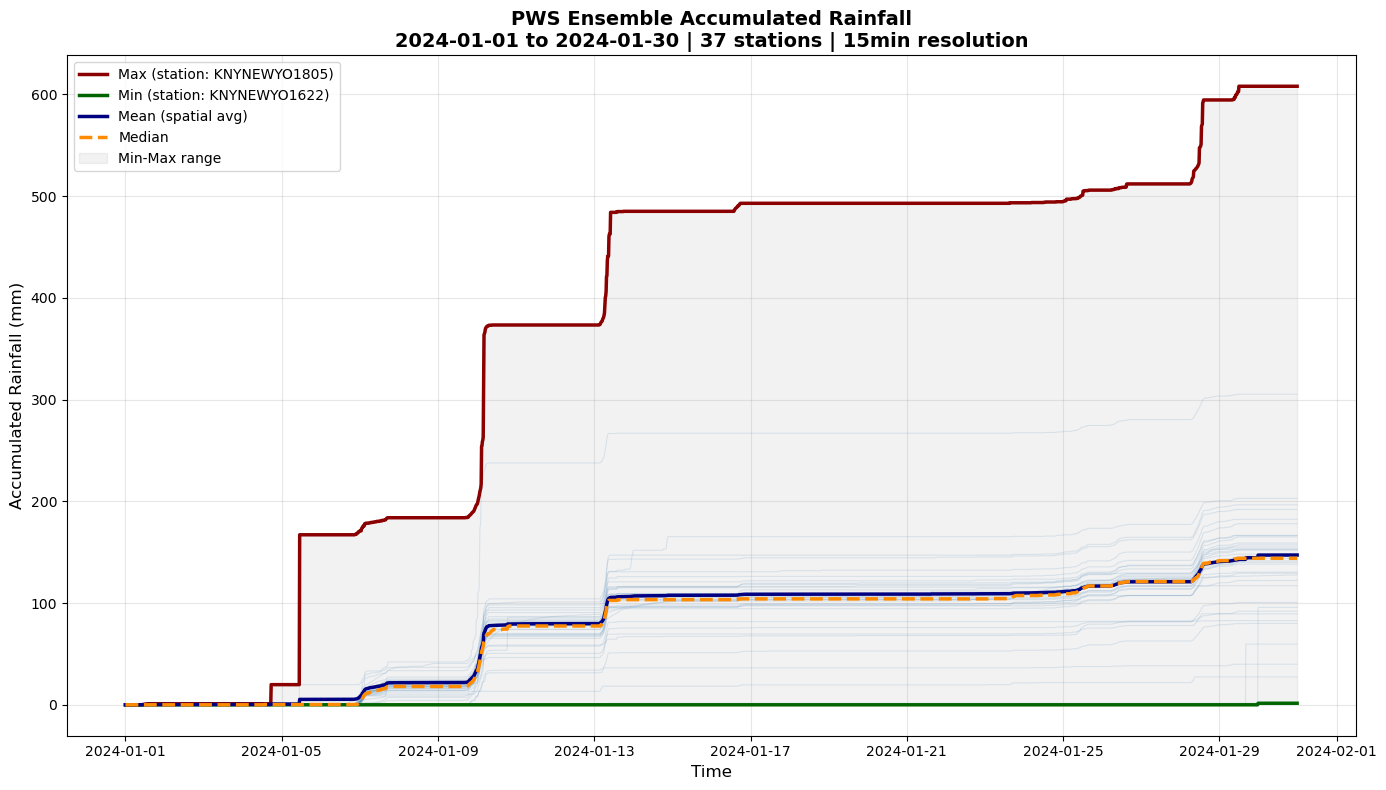


SUMMARY STATISTICS (Final accumulated values)
  Max:    608.1 mm
  Min:    1.5 mm
  Mean:   147.2 mm
  Median: 144.0 mm
  Spread: 606.6 mm

✓ Plotted ensemble for 37 stations


In [49]:


# Ensemble plot - all stations on ONE plot
plot_pws_ensemble_rainfall(pws_data,
                           start_date='2024-01-01',
                           end_date='2024-01-30',
                        #    resample_interval='15min',
                           show_individual=True,filter_top_n=0,filter_bottom_n=0)
# Usage example - Individual subplots per station:
# plot_pws_accumulated_rainfall(pws_data,
#                               start_date='2023-10-28',
#                               end_date='2024-07-01',
#                               station_list=None)  # All stations

Plotting ensemble rainfall for 37 stations
Period: 2023-10-28 to 2024-07-01
Resample interval: 15min
  ✓ Combined 37 stations, 23696 time steps
  ✓ Filtered out 2 lowest stations: ['KNYNEWYO1622', 'KNYNEWYO343']
  ✓ Filtered out 2 highest stations: ['KNYNEWYO1288', 'KNYNEWYO1805']
  ✓ Remaining: 33 stations


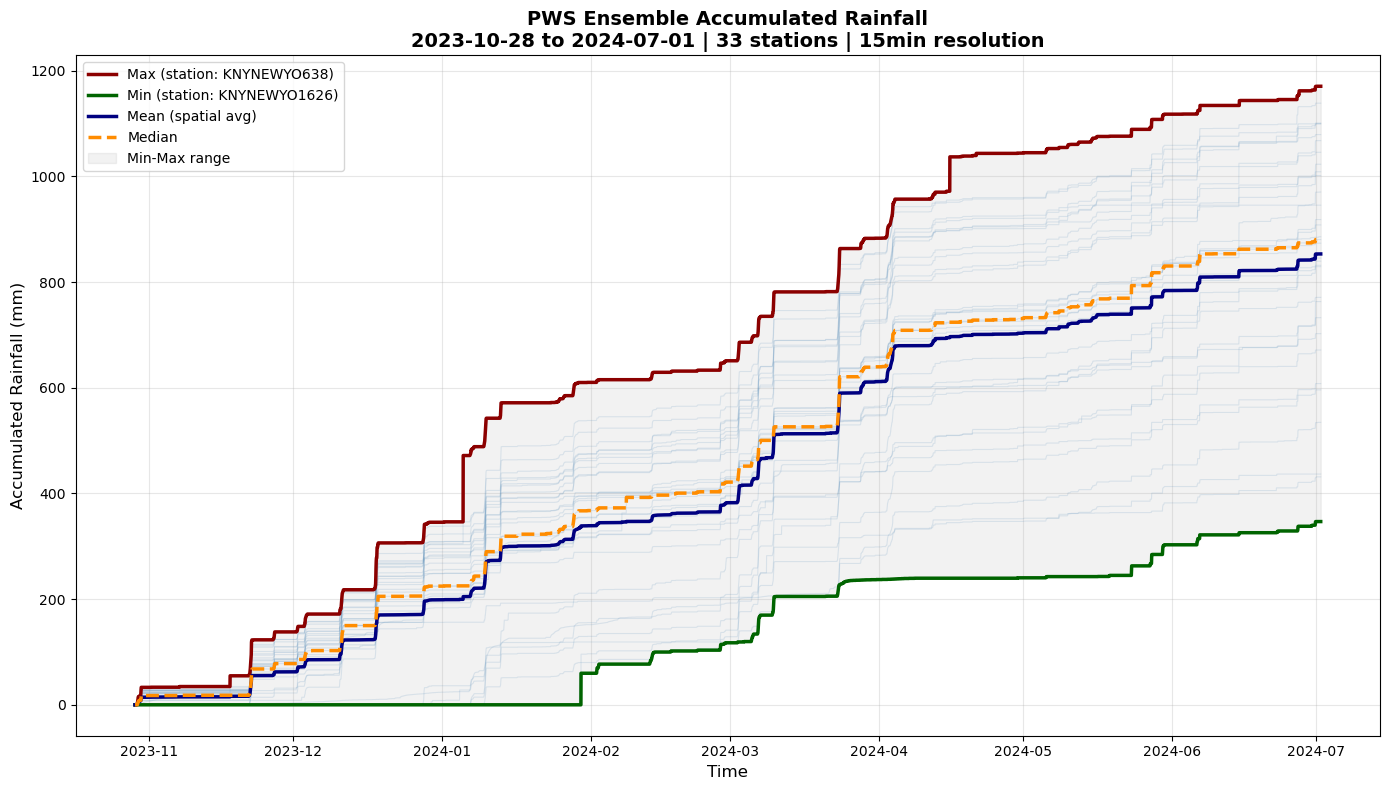


SUMMARY STATISTICS (Final accumulated values)
  Max:    1170.4 mm
  Min:    346.7 mm
  Mean:   853.1 mm
  Median: 880.4 mm
  Spread: 823.7 mm

✓ Plotted ensemble for 33 stations


In [50]:
# Ensemble plot - All stations on ONE plot with spatial aggregation stats
# Shows: individual traces (low alpha) + max/min/mean/median lines
plot_pws_ensemble_rainfall(pws_data,
                           start_date='2023-10-28',
                           end_date='2024-07-01',
                           resample_interval='15min',   # Aggregation interval
                           show_individual=True,        # Show faint individual traces
                           filter_top_n=2,              # Remove 2 highest stations (outliers)
                           filter_bottom_n=2)           # Remove 2 lowest stations (outliers)

## Summary Statistics

In [33]:
print("RAINFALL SUMMARY (Jan 15-30, 2024)")
print("="*70)
print(f"{'Station':<40s} {'Total (mm)':>12s} {'Max Rate (mm/h)':>16s}")
print("-"*70)

for station_name, station_ds in pws_data.items():
    if 'rainfall_amount' in station_ds.data_vars:
        total = float(station_ds['rainfall_amount'].sum().values)
        
        if 'rainfall_rate' in station_ds.data_vars:
            max_rate = float(station_ds['rainfall_rate'].max().values)
            print(f"{station_name:<40s} {total:12.2f} {max_rate:16.2f}")
        else:
            print(f"{station_name:<40s} {total:12.2f} {'N/A':>16s}")

print("="*70)

RAINFALL SUMMARY (Jan 15-30, 2024)
Station                                    Total (mm)  Max Rate (mm/h)
----------------------------------------------------------------------
KNYNEWYO1472                                   885.70            34.80
KNYNEWYO1659                                   839.47           148.34
KNYNEWYO1288                                  1268.98            94.74
KNYNEWYO1896                                   918.21            98.30
KNYNEWYO1921                                   829.06           111.51
KNYNEWYO1931                                   770.89            94.49
KNYNEWYO1313                                  1138.43           102.11
KNYNEWYO1918                                   534.42            59.44
KNYNEWYO1298                                  1008.63            79.25
KNYNEWYO1388                                   763.02           200.91
KNYNEWYO1606                                   908.05            85.09
KNYNEWYO1943                              

## Close Dataset

In [16]:
# Close the netCDF file when done
ds_pws.close()
print("✓ Dataset closed")

✓ Dataset closed
